In [1]:
import json
import sqlite3
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROCESSED_DIR = Path("../data/processed")
VALIDATION_DIR = Path("../data/validation")

MODELO_PRINCIPAL = "openai/gpt-oss-120b"
MODELOS_VALIDACAO = [
    "deepseek/deepseek-v4-flash",
    "google/gemma-4-31b-it",
]
MODELOS = [MODELO_PRINCIPAL] + MODELOS_VALIDACAO

CAMPOS_LISTA = ["skills_tecnicas", "praticas_genai", "ferramentas_ia_codigo"]
CAMPOS_CATEGORICOS = [
    "usa_ia_no_desenvolvimento", "senioridade", "modalidade",
    "exige_ingles", "exige_formacao_superior",
]


def apelido(modelo):
    return modelo.split("/")[-1]


def prf(extraida, referencia):
    extraida, referencia = set(extraida), set(referencia)
    if not extraida and not referencia:
        return 1.0, 1.0, 1.0
    inter = len(extraida & referencia)
    precisao = inter / len(extraida) if extraida else 0.0
    recall = inter / len(referencia) if referencia else 0.0
    f1 = 2 * precisao * recall / (precisao + recall) if precisao + recall else 0.0
    return precisao, recall, f1


AZUL = "#2a78d6"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#52514e",
    "axes.titlecolor": "#0b0b0b",
    "axes.titlelocation": "left",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "ytick.labelcolor": "#52514e",
    "figure.dpi": 110,
})

db = sqlite3.connect(PROCESSED_DIR / "extracao.sqlite")
extracoes = pd.read_sql("SELECT url_base, modelo, json FROM extracoes", db)
extracoes = extracoes[extracoes["modelo"].isin(MODELOS)].reset_index(drop=True)
campos = pd.json_normalize(extracoes["json"].map(json.loads))
extracoes = pd.concat([extracoes[["url_base", "modelo"]], campos], axis=1)

cobertura = extracoes.groupby("url_base")["modelo"].nunique()
completas = sorted(cobertura[cobertura == len(MODELOS)].index)
extracoes = extracoes[extracoes["url_base"].isin(completas)]
por_modelo = {
    modelo: grupo.set_index("url_base").loc[completas]
    for modelo, grupo in extracoes.groupby("modelo")
}

validadas = pd.read_parquet(PROCESSED_DIR / "vagas_validadas.parquet").set_index("url_base")
referencia = validadas.loc[completas]

arbitragem = pd.read_excel(VALIDATION_DIR / "divergencias_arbitragem.xlsx")
anotadas = arbitragem.dropna(subset=["valor_correto"])

print(f"{len(completas)} vagas cobertas pelos 3 modelos · "
      f"{len(anotadas)} de {len(arbitragem)} divergências arbitradas")
if len(anotadas) < len(arbitragem):
    print("ATENÇÃO: arbitragem incompleta — nos campos divergentes não anotados a "
          "referência é o valor do modelo principal, o que o favorece a seguir.")

283 vagas cobertas pelos 3 modelos · 266 de 266 divergências arbitradas


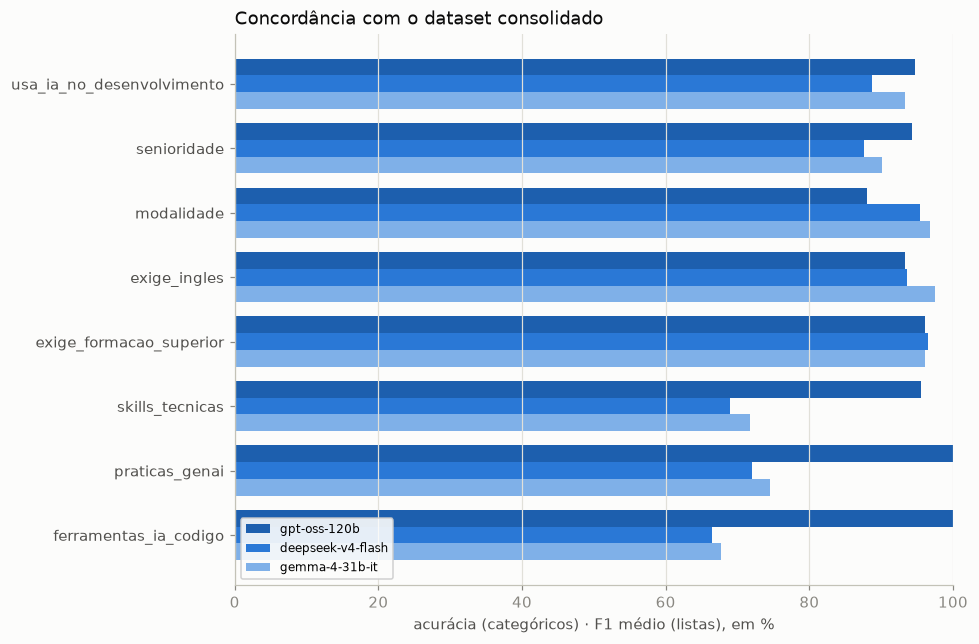

,gpt-oss-120b,deepseek-v4-flash,gemma-4-31b-it
usa_ia_no_desenvolvimento,0.947,0.887,0.933
senioridade,0.943,0.876,0.901
modalidade,0.880,0.954,0.968
exige_ingles,0.933,0.936,0.975
exige_formacao_superior,0.961,0.965,0.961
skills_tecnicas,0.956,0.690,0.717
praticas_genai,1.000,0.721,0.745
ferramentas_ia_codigo,1.000,0.664,0.677


In [2]:
acuracia_cat = pd.DataFrame({
    apelido(modelo): {
        campo: (por_modelo[modelo][campo].astype(str).to_numpy()
                == referencia[campo].astype(str).to_numpy()).mean()
        for campo in CAMPOS_CATEGORICOS
    }
    for modelo in MODELOS
})
f1_listas = pd.DataFrame({
    apelido(modelo): {
        campo: np.mean([prf(e, r)[2] for e, r in
                        zip(por_modelo[modelo][campo], referencia[campo])])
        for campo in CAMPOS_LISTA
    }
    for modelo in MODELOS
})
quadro = pd.concat([acuracia_cat, f1_listas])

cores = ["#1d5fae", "#2a78d6", "#7fb0e8"]
y = np.arange(len(quadro))[::-1]
altura = 0.26
fig, ax = plt.subplots(figsize=(9, 0.62 * len(quadro) + 1))
for i, (coluna, cor) in enumerate(zip(quadro.columns, cores)):
    ax.barh(y + (1 - i) * altura, quadro[coluna] * 100, height=altura,
            color=cor, label=coluna)
ax.set_yticks(y, quadro.index)
ax.set_title("Concordância com o dataset consolidado")
ax.set_xlabel("acurácia (categóricos) · F1 médio (listas), em %")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()

quadro.round(3)

In [3]:
categoricas = anotadas[anotadas["campo"].isin(CAMPOS_CATEGORICOS)]
taxas = pd.Series(dtype=float)

if len(categoricas):
    correta = categoricas["valor_correto"].astype(str).str.strip().str.lower()
    acertos = pd.DataFrame({
        apelido(modelo): categoricas[modelo].astype(str).str.strip().str.lower()
                         .eq(correta).to_numpy()
        for modelo in MODELOS
    })
    taxas = acertos.mean()
    print(f"acerto geral nas {len(categoricas)} divergências categóricas arbitradas:")
    print(taxas.round(3).to_string())
    quadro_arb = acertos.assign(campo=categoricas["campo"].to_numpy()).groupby("campo").mean()
    print("\npor campo:")
    print(quadro_arb.round(2).to_string())
else:
    print("nenhuma divergência categórica arbitrada — anote a planilha da etapa 4 antes.")

acerto geral nas 219 divergências categóricas arbitradas:
gpt-oss-120b         0.566
deepseek-v4-flash    0.507
gemma-4-31b-it       0.662

por campo:
                           gpt-oss-120b  deepseek-v4-flash  gemma-4-31b-it
campo                                                                     
exige_formacao_superior            0.54               0.58            0.54
exige_ingles                       0.44               0.47            0.79
modalidade                         0.26               0.72            0.80
senioridade                        0.73               0.42            0.53
usa_ia_no_desenvolvimento          0.73               0.42            0.65


In [4]:
from scipy.stats import friedmanchisquare, wilcoxon


def holm(pares):
    ordenados = sorted(pares.items(), key=lambda kv: kv[1])
    ajustados, teto = {}, 0.0
    for i, (par, p) in enumerate(ordenados):
        teto = max(teto, (len(ordenados) - i) * p)
        ajustados[par] = min(1.0, teto)
    return ajustados


escores_cat = pd.DataFrame({
    modelo: (por_modelo[modelo][CAMPOS_CATEGORICOS].astype(str).to_numpy()
             == referencia[CAMPOS_CATEGORICOS].astype(str).to_numpy()).mean(axis=1)
    for modelo in MODELOS
}, index=completas)
escores_f1 = pd.DataFrame({
    modelo: [prf(e, r)[2] for e, r in
             zip(por_modelo[modelo]["skills_tecnicas"], referencia["skills_tecnicas"])]
    for modelo in MODELOS
}, index=completas)

friedman_resultados = {}
for nome, escores in [("categóricos (proporção correta por vaga)", escores_cat),
                      ("skills técnicas (F1 por vaga)", escores_f1)]:
    chi2, p = friedmanchisquare(*(escores[m] for m in MODELOS))
    friedman_resultados[nome] = p
    print(f"— {nome}: χ² = {chi2:.1f} · p = {p:.2g}")
    print(escores.mean().rename(apelido).round(3).to_string())
    if p < 0.05:
        pares = {
            f"{apelido(a)} × {apelido(b)}":
                wilcoxon(escores[a] - escores[b], zero_method="zsplit").pvalue
            for a, b in combinations(MODELOS, 2)
        }
        print("post-hoc Wilcoxon (p ajustado por Holm):")
        for par, pv in holm(pares).items():
            print(f"  {par}: {pv:.2g}")
    print()

— categóricos (proporção correta por vaga): χ² = 7.7 · p = 0.021
gpt-oss-120b         0.933
deepseek-v4-flash    0.924
gemma-4-31b-it       0.948
post-hoc Wilcoxon (p ajustado por Holm):
  deepseek-v4-flash × gemma-4-31b-it: 0.051
  gpt-oss-120b × gemma-4-31b-it: 0.43
  gpt-oss-120b × deepseek-v4-flash: 0.43

— skills técnicas (F1 por vaga): χ² = 317.9 · p = 9.2e-70
gpt-oss-120b         0.956
deepseek-v4-flash    0.690
gemma-4-31b-it       0.717
post-hoc Wilcoxon (p ajustado por Holm):
  gpt-oss-120b × deepseek-v4-flash: 1.1e-38
  gpt-oss-120b × gemma-4-31b-it: 1e-37
  deepseek-v4-flash × gemma-4-31b-it: 0.015



In [5]:
from statsmodels.stats.contingency_tables import mcnemar

N_BOOTSTRAP = 1000
gerador = np.random.default_rng(42)
reamostras = gerador.integers(0, len(completas), size=(N_BOOTSTRAP, len(completas)))

acertos_por_campo = {
    campo: pd.DataFrame({
        modelo: por_modelo[modelo][campo].astype(str).to_numpy()
                == referencia[campo].astype(str).to_numpy()
        for modelo in MODELOS
    }, index=completas)
    for campo in CAMPOS_CATEGORICOS
}

linhas = []
for campo, acertos in acertos_por_campo.items():
    brutos, dados = {}, {}
    for a, b in combinations(MODELOS, 2):
        certo_a, certo_b = acertos[a].to_numpy(), acertos[b].to_numpy()
        so_a = int((certo_a & ~certo_b).sum())
        so_b = int((certo_b & ~certo_a).sum())
        tabela = [[int((certo_a & certo_b).sum()), so_a],
                  [so_b, int((~certo_a & ~certo_b).sum())]]
        difs = certo_a[reamostras].mean(axis=1) - certo_b[reamostras].mean(axis=1)
        ic_baixo, ic_alto = np.percentile(difs, [2.5, 97.5])
        par = f"{apelido(a)} × {apelido(b)}"
        brutos[par] = mcnemar(tabela, exact=True).pvalue if so_a + so_b else 1.0
        dados[par] = {
            "campo": campo, "par": par,
            "acuracia_a": certo_a.mean(), "acuracia_b": certo_b.mean(),
            "diferenca": certo_a.mean() - certo_b.mean(),
            "ic95_baixo": ic_baixo, "ic95_alto": ic_alto,
            "so_a": so_a, "so_b": so_b, "discordantes": so_a + so_b,
            "p": brutos[par],
        }
    for par, p_ajustado in holm(brutos).items():
        linhas.append({**dados[par], "p_holm": p_ajustado})

mcnemar_cat = pd.DataFrame(linhas).set_index(["campo", "par"])

print("McNemar exato pareado vs consolidado · Holm sobre as 3 comparações de cada campo")
print(f"IC 95% da diferença de acurácia por bootstrap de vagas ({N_BOOTSTRAP} reamostragens)\n")
for campo, bloco in mcnemar_cat.groupby(level="campo", sort=False):
    print(f"— {campo}")
    for (_, par), linha in bloco.iterrows():
        marca = "*" if linha["p_holm"] < 0.05 else " "
        print(f" {marca} {par:<36} Δacc {linha['diferenca']:+.3f} "
              f"[{linha['ic95_baixo']:+.3f}, {linha['ic95_alto']:+.3f}] · "
              f"só A/só B {int(linha['so_a']):>2}/{int(linha['so_b']):<2} · "
              f"p {linha['p']:.3g} → Holm {linha['p_holm']:.3g}")
    print()

print("nas vagas em que os 3 concordam a referência é o próprio consenso: os 3 acertam "
      "por construção,\ncélulas concordantes que o McNemar descarta e que encolhem a "
      "diferença de acurácia — o IC é\nsobre as 283 vagas, o teste é sobre as discordantes.")

mcnemar_cat.round(4)


McNemar exato pareado vs consolidado · Holm sobre as 3 comparações de cada campo
IC 95% da diferença de acurácia por bootstrap de vagas (1000 reamostragens)

— usa_ia_no_desenvolvimento
 * gpt-oss-120b × deepseek-v4-flash     Δacc +0.060 [+0.014, +0.106] · só A/só B 31/14 · p 0.0161 → Holm 0.0483
   deepseek-v4-flash × gemma-4-31b-it   Δacc -0.046 [-0.088, -0.004] · só A/só B 12/25 · p 0.047 → Holm 0.0941
   gpt-oss-120b × gemma-4-31b-it        Δacc +0.014 [-0.021, +0.049] · só A/só B 16/12 · p 0.572 → Holm 0.572

— senioridade
 * gpt-oss-120b × deepseek-v4-flash     Δacc +0.067 [+0.021, +0.117] · só A/só B 34/15 · p 0.0094 → Holm 0.0282
 * gpt-oss-120b × gemma-4-31b-it        Δacc +0.042 [+0.011, +0.078] · só A/só B 18/6  · p 0.0227 → Holm 0.0453
   deepseek-v4-flash × gemma-4-31b-it   Δacc -0.025 [-0.074, +0.025] · só A/só B 20/27 · p 0.382 → Holm 0.382

— modalidade
 * gpt-oss-120b × gemma-4-31b-it        Δacc -0.088 [-0.131, -0.046] · só A/só B  6/31 · p 4.13e-05 → Holm 0.000124
 *

acuracia_a  \
campo                     par                                              
usa_ia_no_desenvolvimento gpt-oss-120b × deepseek-v4-flash        0.9470   
                          deepseek-v4-flash × gemma-4-31b-it      0.8869   
                          gpt-oss-120b × gemma-4-31b-it           0.9470   
senioridade               gpt-oss-120b × deepseek-v4-flash        0.9435   
                          gpt-oss-120b × gemma-4-31b-it           0.9435   
                          deepseek-v4-flash × gemma-4-31b-it      0.8763   
modalidade                gpt-oss-120b × gemma-4-31b-it           0.8799   
                          gpt-oss-120b × deepseek-v4-flash        0.8799   
                          deepseek-v4-flash × gemma-4-31b-it      0.9541   
exige_ingles              gpt-oss-120b × gemma-4-31b-it           0.9329   
                          deepseek-v4-flash × gemma-4-31b-it      0.9364   
                          gpt-oss-120b × deepseek-v4-flash        0.9329   
exige_formacao_superior   gpt-oss-120b × deepseek-v4-flash        0.9611   
                          gpt-oss-120b × gemma-4-31b-it           0.9611   
                          deepseek-v4-flash × gemma-4-31b-it      0.9647   

                                                              acuracia_b  \
campo                     par                                              
usa_ia_no_desenvolvimento gpt-oss-120b × deepseek-v4-flash        0.8869   
                          deepseek-v4-flash × gemma-4-31b-it      0.9329   
                          gpt-oss-120b × gemma-4-31b-it           0.9329   
senioridade               gpt-oss-120b × deepseek-v4-flash        0.8763   
                          gpt-oss-120b × gemma-4-31b-it           0.9011   
                          deepseek-v4-flash × gemma-4-31b-it      0.9011   
modalidade                gpt-oss-120b × gemma-4-31b-it           0.9682   
                          gpt-oss-120b × deepseek-v4-flash        0.9541   
                          deepseek-v4-flash × gemma-4-31b-it      0.9682   
exige_ingles              gpt-oss-120b × gemma-4-31b-it           0.9753   
                          deepseek-v4-flash × gemma-4-31b-it      0.9753   
                          gpt-oss-120b × deepseek-v4-flash        0.9364   
exige_formacao_superior   gpt-oss-120b × deepseek-v4-flash        0.9647   
                          gpt-oss-120b × gemma-4-31b-it           0.9611   
                          deepseek-v4-flash × gemma-4-31b-it      0.9611   

                                                              diferenca  \
campo                     par                                             
usa_ia_no_desenvolvimento gpt-oss-120b × deepseek-v4-flash       0.0601   
                          deepseek-v4-flash × gemma-4-31b-it    -0.0459   
                          gpt-oss-120b × gemma-4-31b-it          0.0141   
senioridade               gpt-oss-120b × deepseek-v4-flash       0.0671   
                          gpt-oss-120b × gemma-4-31b-it          0.0424   
                          deepseek-v4-flash × gemma-4-31b-it    -0.0247   
modalidade                gpt-oss-120b × gemma-4-31b-it         -0.0883   
                          gpt-oss-120b × deepseek-v4-flash      -0.0742   
                          deepseek-v4-flash × gemma-4-31b-it    -0.0141   
exige_ingles              gpt-oss-120b × gemma-4-31b-it         -0.0424   
                          deepseek-v4-flash × gemma-4-31b-it    -0.0389   
                          gpt-oss-120b × deepseek-v4-flash      -0.0035   
exige_formacao_superior   gpt-oss-120b × deepseek-v4-flash      -0.0035   
                          gpt-oss-120b × gemma-4-31b-it          0.0000   
                          deepseek-v4-flash × gemma-4-31b-it     0.0035   

                                                              ic95_baixo  \
campo                     par                                              
usa_ia_no_desenvolvimento gpt-oss-120b × deepsee

In [6]:
ARQUIVO_VERIFICACAO = VALIDATION_DIR / "verificacao_unanimidade.xlsx"
N_AMOSTRA = 15

divergentes = set(arbitragem["url_base"])
unanimes = [url for url in completas if url not in divergentes]
print(f"{len(unanimes)} vagas sem nenhuma divergência entre os 3 modelos")

if ARQUIVO_VERIFICACAO.exists():
    print(f"{ARQUIVO_VERIFICACAO} já existe — mantido para não sobrescrever anotações.")
else:
    amostra = referencia.loc[unanimes].sample(
        min(N_AMOSTRA, len(unanimes)), random_state=42)
    export = amostra[["job_title", "company", "descricao"]
                     + CAMPOS_CATEGORICOS + CAMPOS_LISTA].copy()
    for campo in CAMPOS_LISTA:
        export[campo] = export[campo].map("; ".join)
    export["campos_errados"] = None
    export.reset_index().to_excel(ARQUIVO_VERIFICACAO, index=False)
    print(f"amostra de {len(export)} vagas exportada para {ARQUIVO_VERIFICACAO}")

113 vagas sem nenhuma divergência entre os 3 modelos
..\data\validation\verificacao_unanimidade.xlsx já existe — mantido para não sobrescrever anotações.


In [7]:
erro_unanimidade = None
if ARQUIVO_VERIFICACAO.exists():
    verificacao = pd.read_excel(ARQUIVO_VERIFICACAO)
    lidas = verificacao.dropna(subset=["campos_errados"])
    if len(lidas):
        com_erro = lidas["campos_errados"].astype(str).str.strip().str.lower().ne("ok")
        erro_unanimidade = com_erro.mean()
        print(f"{len(lidas)} vagas lidas · {com_erro.sum()} com algum campo errado "
              f"({erro_unanimidade:.0%})")
        campos_errados = (
            lidas.loc[com_erro, "campos_errados"]
            .str.split(";").explode().str.strip().value_counts()
        )
        if len(campos_errados):
            print(campos_errados.to_string())
    else:
        print("planilha ainda sem anotações — leia a amostra e preencha campos_errados.")

15 vagas lidas · 10 com algum campo errado (67%)
campos_errados
skills_tecnicas              4
praticas_genai               3
modalidade                   2
ferramentas_ia_codigo        2
usa_ia_no_desenvolvimento    2


In [8]:
sintese = {
    "vagas no estudo": len(validadas),
    "cobertas pelos 3 modelos": f"{len(completas)} ({len(completas) / len(validadas):.1%})",
    "divergências arbitradas": f"{len(anotadas)} de {len(arbitragem)}",
    "acurácia média do principal vs consolidado (categóricos)":
        f"{acuracia_cat[apelido(MODELO_PRINCIPAL)].mean():.1%}",
    "F1 médio do principal vs consolidado (skills)":
        f"{f1_listas[apelido(MODELO_PRINCIPAL)]['skills_tecnicas']:.3f}",
}
if len(taxas):
    sintese["acerto do principal nas divergências arbitradas"] = (
        f"{taxas[apelido(MODELO_PRINCIPAL)]:.0%}"
    )
for nome, p in friedman_resultados.items():
    sintese[f"Friedman · {nome}"] = f"p = {p:.2g}"
if erro_unanimidade is not None:
    sintese["erro na amostra de vagas unânimes"] = f"{erro_unanimidade:.0%}"

for chave, valor in sintese.items():
    print(f"{chave}: {valor}")

vagas no estudo: 283
cobertas pelos 3 modelos: 283 (100.0%)
divergências arbitradas: 266 de 266
acurácia média do principal vs consolidado (categóricos): 93.3%
F1 médio do principal vs consolidado (skills): 0.956
acerto do principal nas divergências arbitradas: 57%
Friedman · categóricos (proporção correta por vaga): p = 0.021
Friedman · skills técnicas (F1 por vaga): p = 9.2e-70
erro na amostra de vagas unânimes: 67%
